# Time-Series Data Preparation for Deep Learning
### From **univariate** to **multivariate** sequence-to-sequence forecasting

We download daily **adjusted close** prices for **AAPL** and **GOOG** and turn them into the
3-D tensors a Keras/PyTorch recurrent or convolutional model expects.

> **The one shape you must memorise**
> ```
> X  ->  (samples, timesteps, features)
> ```
> *samples* = how many sliding windows we cut,
> *timesteps* = how far back the model looks (`N_STEPS_IN`),
> *features* = how many parallel series we feed it (1 = univariate, 2 = AAPL + GOOG).
>
> Going from univariate to multivariate changes **only the last number**. Everything else is identical.

---

## Contents
| # | Section | What you learn |
|---|---------|----------------|
| 1 | [Setup & configuration](#1) | Every tunable knob in one cell |
| 2 | [Download the data](#2) | `yfinance`, adjusted vs raw close |
| 3 | [Visualise the raw series](#3) | Why two tickers *need* scaling |
| 4 | [Univariate → multivariate](#4) | The feature matrix `(T, n_features)` |
| 5 | [Chronological split](#5) | Never shuffle time series; purge gaps |
| 6 | [Scaling without leakage](#6) | `fit` on train, `transform` on test |
| 7 | [The sliding-window function](#7) | One function for uni *and* multivariate |
| 8 | [Build & inspect the samples](#8) | Verify shapes, dates and alignment |
| 9 | [Visualise the windows](#9) | *See* what the model actually reads |
| 10 | [Keras-ready tensors](#10) | Final shapes + safety assertions |
| 11 | [Recap & exercises](#11) | Check your understanding |

---
<a id="1"></a>
## 1. Setup & configuration

Everything you might want to change lives in the next cell. Change a value there,
then **Run All** — no other cell needs editing.


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# =============================================================================
#  CONFIGURATION  -  the only cell you need to edit
# =============================================================================

# ---- 1. WHICH DATA TO DOWNLOAD ---------------------------------------------
TICKERS  = ['AAPL', 'GOOG']  # any yfinance symbols. 1 symbol = univariate,
                             # 2+ = multivariate. Try ['AAPL','GOOG','MSFT'].
START    = '2015-01-01'      # first date to download (YYYY-MM-DD)
END      = None              # None = up to today, or e.g. '2024-12-31'
INTERVAL = '1d'              # '1d' daily | '1wk' weekly | '1mo' monthly.
                             # Intraday ('1h','5m') only goes back ~60-730 days.

# ---- 2. WHAT THE MODEL SEES AND WHAT IT PREDICTS ----------------------------
TARGET_MODE = 'MISO'         # 'MISO' = many inputs -> ONE series forecast
                             #          y shape (samples, N_STEPS_OUT)
                             # 'MIMO' = many inputs -> ALL series forecast
                             #          y shape (samples, N_STEPS_OUT, n_features)
                             # Start with MISO: the error is easy to interpret
                             # because it is measured in one stock's dollars.
TARGET      = 'AAPL'         # which ticker to forecast (ignored when MIMO)

N_STEPS_IN  = 100            # look-back window: how many past days go into X.
                             # Bigger = more context but fewer samples and a
                             # harder optimisation. Typical: 20-120 for daily.
N_STEPS_OUT = 30             # forecast horizon: how many future days in y.
                             # 1 = one-step forecast, >1 = multi-step.

# ---- 3. HOW THE DATA IS SPLIT AND SCALED -----------------------------------
TRAIN_FRAC = 0.8             # fraction of the timeline used for training.
                             # The split is CHRONOLOGICAL (past -> train,
                             # future -> test). Never shuffle before splitting.
PURGE      = True            # True = drop a buffer of bars between train and
                             # test so the two sets cannot touch at all.
                             # Set False to see how many samples it costs you.
SCALER     = 'minmax'        # 'minmax'   -> squash to [0,1]  (pairs with sigmoid)
                             # 'standard' -> zero mean / unit variance
                             # 'none'     -> keep raw dollars (readable, but the
                             #               loss is dominated by the pricier stock)

# ---- 4. DISPLAY OPTIONS -----------------------------------------------------
N_PREVIEW_SAMPLES = 2        # how many windows to print in the inspection cell
N_PREVIEW_STEPS   = 5        # how many timesteps of each window to print

np.set_printoptions(precision=3, suppress=True, linewidth=140)
pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f"Config OK  |  {len(TICKERS)} ticker(s) -> "
      f"{'univariate' if len(TICKERS) == 1 else 'multivariate'} input"
      f"  |  mode={TARGET_MODE}  |  {N_STEPS_IN} days in -> {N_STEPS_OUT} days out")


Config OK  |  2 ticker(s) -> multivariate input  |  mode=MISO  |  100 days in -> 30 days out


<a id="2"></a>
## 2. Download the data with `yfinance`

We ask for **daily adjusted close** for both tickers and keep the result in `df`.

**Adjusted vs raw close.** A stock split does not destroy value, but it does divide the
quoted price (AAPL split 4-for-1 in 2020, GOOG 20-for-1 in 2022). The *raw* close therefore
contains vertical cliffs that look like 75–95% crashes. *Adjusted* close rewrites history so
the series is continuous. `auto_adjust=True` gives you exactly that in the `Close` column.

**Why `dropna()`?** Different exchanges/listings can have a day the other does not. Dropping
rows where *any* ticker is missing keeps all series on one shared calendar, which is required
before we stack them into a single matrix.


In [2]:
# auto_adjust=True -> the 'Close' column IS the ADJUSTED close: stock splits and
# dividends are already baked in. Leave it True. With auto_adjust=False you get
# the raw close, which contains artificial cliffs on split days (AAPL 4:1 in 2020,
# GOOG 20:1 in 2022) that no model can learn - it would just see a 75% "crash".
raw = yf.download(TICKERS, start=START, end=END, interval=INTERVAL,
                  auto_adjust=True, progress=False)

df = raw['Close'][TICKERS].copy()   # keep only adjusted close, in TICKERS order
df.columns.name = None
df = df.dropna()                    # drop days where ANY ticker is missing, so all
                                    # series stay aligned on a single shared calendar

# ---------------------------------------------------------------- inspection
print(f"Downloaded {df.shape[0]} rows x {df.shape[1]} columns "
      f"({df.index[0].date()} -> {df.index[-1].date()})\n")

print("Missing values per column:")
print(df.isna().sum().to_string(), "\n")

print("Summary statistics (note how different the two price levels are):")
print(df.describe().T[['min', 'mean', 'max', 'std']].round(2), "\n")

print("First 3 rows:");  print(df.head(3).round(2))
print("\nLast 3 rows:");  print(df.tail(3).round(2))

# The index is a DatetimeIndex of TRADING days: weekends and holidays are simply
# absent, so row i+1 is "the next trading day", not always "tomorrow".
# We treat the rows as an evenly spaced sequence - the standard simplification.
gaps = df.index.to_series().diff().dt.days.value_counts().head(4)
print("\nGap in calendar days between consecutive rows (count):")
print(gaps.to_string())

df


Downloaded 2926 rows x 2 columns (2015-01-02 -> 2026-08-21)

Missing values per column:
AAPL    0
GOOG    0 

Summary statistics (note how different the two price levels are):
        min    mean     max    std
AAPL  20.55  115.71  339.79  82.74
GOOG  24.35  107.17  398.80  79.69 

First 3 rows:
             AAPL   GOOG
Date                    
2015-01-02  24.17  25.94
2015-01-05  23.49  25.40
2015-01-06  23.49  24.81

Last 3 rows:
              AAPL    GOOG
Date                      
2026-08-19  316.83  341.70
2026-08-20  311.30  338.20
2026-08-21  309.35  341.75

Gap in calendar days between consecutive rows (count):
Date
1.0    2290
3.0     525
4.0      82
2.0      28


,AAPL,GOOG
Date,,
2015-01-02,24.171759,25.939949
2015-01-05,23.490799,25.399214
2015-01-06,23.493015,24.810537
2015-01-07,23.822430,24.768026
2015-01-08,24.737745,24.846123
...,...,...
2026-08-17,305.589996,341.450012
2026-08-18,310.029999,341.279999
2026-08-19,316.829987,341.700012


<a id="3"></a>
## 3. Visualise the raw series

Always plot before you model. Two things to look for here:

1. **Scale mismatch.** The two tickers trade at very different dollar levels. Mean-squared
   error is computed on raw numbers, so without scaling the loss would be dominated by
   whichever series has the larger range — the network would effectively ignore the other one.
2. **Correlation.** If a second feature is perfectly correlated with the first it adds
   parameters without adding information. Price *levels* almost always look ~0.9+ correlated
   (both trend upward); daily *returns* are the honest measure of shared information.


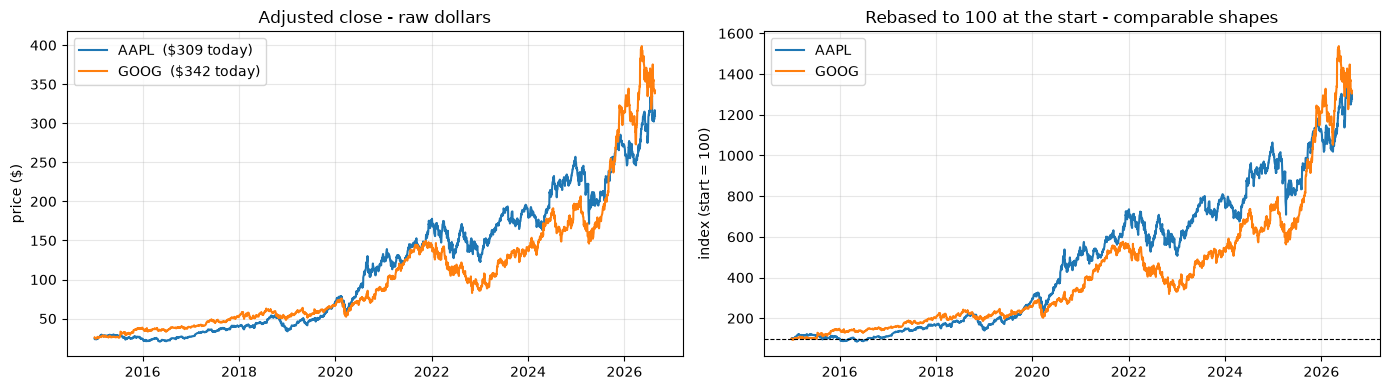

Correlation of price levels:
        AAPL   GOOG
AAPL  1.000  0.933
GOOG  0.933  1.000 

Correlation of daily returns:
       AAPL  GOOG
AAPL  1.00  0.56
GOOG  0.56  1.00


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Left: real prices. The point of this plot is that the two series live on
# different numeric scales -> an unscaled MSE loss would be ~dominated by one.
for col in df.columns:
    ax[0].plot(df.index, df[col], label=f"{col}  (${df[col].iloc[-1]:,.0f} today)")
ax[0].set_title("Adjusted close - raw dollars")
ax[0].set_ylabel("price ($)")
ax[0].legend()

# Right: same data rebased so every series starts at 100. Now you compare SHAPE
# (relative growth), which is what a scaled model effectively learns.
rebased = df / df.iloc[0] * 100
for col in rebased.columns:
    ax[1].plot(rebased.index, rebased[col], label=col)
ax[1].axhline(100, color='k', lw=0.8, ls='--')
ax[1].set_title("Rebased to 100 at the start - comparable shapes")
ax[1].set_ylabel("index (start = 100)")
ax[1].legend()

plt.tight_layout()
plt.show()

# Correlation tells you whether the extra ticker carries NEW information.
# ~1.0 on price levels is misleading (both just trend up), so also look at
# daily returns, which is what actually drives short-horizon forecasts.
print("Correlation of price levels:\n", df.corr().round(3), "\n")
print("Correlation of daily returns:\n", df.pct_change().dropna().corr().round(3))


<a id="4"></a>
## 4. Univariate → multivariate: it is one extra axis

The original notebook did this:

```python
data_array = df[['price']].to_numpy()
data_array = data_array.reshape(data_array.shape[0])   # -> (T,)   1-D
```

That `reshape` **threw the feature axis away**, which is fine with one series and impossible
with two. The multivariate version simply keeps the 2-D matrix:

$$\text{data} \in \mathbb{R}^{T \times F}
\qquad
\begin{bmatrix}
\text{AAPL}_1 & \text{GOOG}_1\\
\text{AAPL}_2 & \text{GOOG}_2\\
\vdots & \vdots\\
\text{AAPL}_T & \text{GOOG}_T
\end{bmatrix}$$

Every row is one day; every column is one feature. Univariate is just $F = 1$ — the special
case, not a different algorithm.

`target_idx` records **which column we forecast**. In `MISO` mode it points at `TARGET`;
in `MIMO` mode it is `None`, meaning "keep all columns in `y`".


In [4]:
# --- the ORIGINAL univariate way (one column, flattened to 1-D) --------------
univariate_array = df[[TARGET]].to_numpy().reshape(-1)
print(f"univariate : {univariate_array.shape}  <- (timesteps,)          1-D")

# --- the multivariate way: keep every column -> a 2-D FEATURE MATRIX --------
feature_cols = list(df.columns)          # ['AAPL', 'GOOG'] - the model's inputs
n_features   = len(feature_cols)         # the LAST number of the X tensor
data         = df[feature_cols].to_numpy(dtype='float64')   # (timesteps, features)
dates        = df.index                  # kept aside so we can label plots later

print(f"multivariate: {data.shape}  <- (timesteps, features)  2-D")
print(f"\nfeature order (column index -> name): "
      f"{dict(enumerate(feature_cols))}")

# Which column do we forecast? None means "forecast them all" (MIMO).
target_idx = feature_cols.index(TARGET) if TARGET_MODE == 'MISO' else None
print(f"TARGET_MODE={TARGET_MODE}  ->  target_idx={target_idx}"
      f"{'  (forecasting ' + TARGET + ')' if target_idx is not None else '  (forecasting every feature)'}")

# Sanity check: the univariate array is literally one column of the matrix.
assert np.allclose(univariate_array, data[:, feature_cols.index(TARGET)])
print("\nCheck passed: univariate data == column", feature_cols.index(TARGET),
      "of the feature matrix -> univariate is just the n_features=1 special case.")

print("\nFirst 3 rows of the feature matrix:")
print(data[:3])


univariate : (2926,)  <- (timesteps,)          1-D
multivariate: (2926, 2)  <- (timesteps, features)  2-D

feature order (column index -> name): {0: 'AAPL', 1: 'GOOG'}
TARGET_MODE=MISO  ->  target_idx=0  (forecasting AAPL)

Check passed: univariate data == column 0 of the feature matrix -> univariate is just the n_features=1 special case.

First 3 rows of the feature matrix:
[[24.172 25.94 ]
 [23.491 25.399]
 [23.493 24.811]]


<a id="5"></a>
## 5. Chronological split (and the purge gap)

**Rule one of time series: never shuffle before splitting.** `train_test_split(shuffle=True)`
would put tomorrow in the training set and yesterday in the test set. The model would then be
"predicting" values it has effectively already seen, and your test score would be fiction.

**Order of operations matters.** We split the *raw timeline first*, then window each half
separately. If you window first and split after, windows near the boundary contain rows from
both sides — training inputs literally include test data.

**The purge gap.** Because we split first, overlap is already zero. `PURGE` throws away one
extra window's worth of bars (`N_STEPS_IN + N_STEPS_OUT`) between the two sets. It costs a
handful of samples and buys you a guarantee that survives future refactors of this notebook.


total rows      : 2926
train           : (2340, 2)  2015-01-02 -> 2024-04-19
purge gap       : 130 rows discarded
test            : (456, 2)  2024-10-25 -> 2026-08-21

usable windows  : train 2211 | test 327


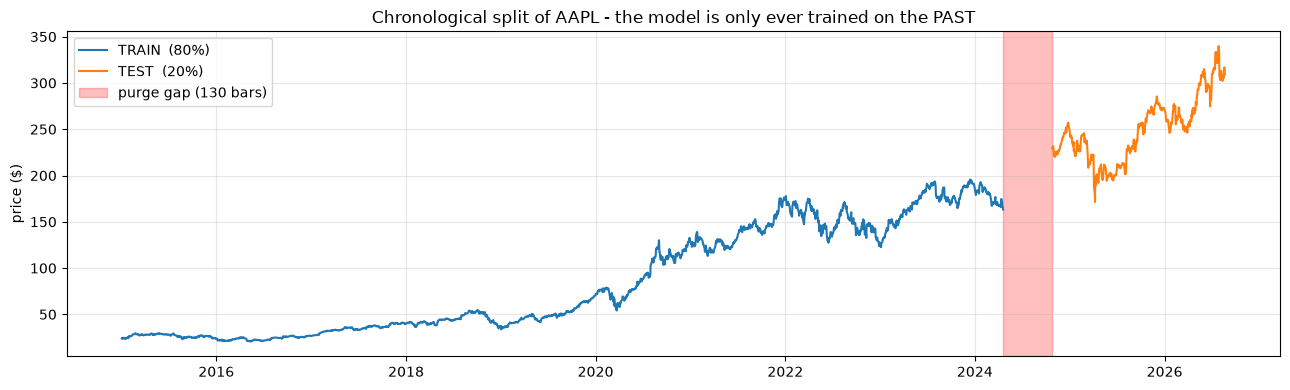

In [5]:
T = len(data)
train_size = int(T * TRAIN_FRAC)     # TRAIN_FRAC=0.8 -> oldest 80% of the timeline

# PURGE GAP: rows thrown away between train and test.
# A single window spans N_STEPS_IN + N_STEPS_OUT rows. Dropping that many bars
# guarantees no test window can ever share a row with a training window, even if
# you later change the code to window FIRST and split afterwards (a classic bug).
gap = (N_STEPS_IN + N_STEPS_OUT) if PURGE else 0

train_data,  train_dates = data[:train_size],       dates[:train_size]
test_data,   test_dates  = data[train_size + gap:], dates[train_size + gap:]

print(f"total rows      : {T}")
print(f"train           : {train_data.shape}  {train_dates[0].date()} -> {train_dates[-1].date()}")
print(f"purge gap       : {gap} rows discarded")
print(f"test            : {test_data.shape}  {test_dates[0].date()} -> {test_dates[-1].date()}")
print(f"\nusable windows  : train {len(train_data) - N_STEPS_IN - N_STEPS_OUT + 1}"
      f" | test {len(test_data) - N_STEPS_IN - N_STEPS_OUT + 1}")

# ------------------------------------------------------------------ visualise
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_dates, train_data[:, feature_cols.index(TARGET)],
        color='tab:blue', label=f'TRAIN  ({TRAIN_FRAC:.0%})')
ax.plot(test_dates,  test_data[:, feature_cols.index(TARGET)],
        color='tab:orange', label=f'TEST  ({1 - TRAIN_FRAC:.0%})')
if gap:
    ax.axvspan(train_dates[-1], test_dates[0], color='red', alpha=0.25,
               label=f'purge gap ({gap} bars)')
ax.set_title(f"Chronological split of {TARGET} - the model is only ever trained on the PAST")
ax.set_ylabel("price ($)")
ax.legend()
plt.tight_layout()
plt.show()


<a id="6"></a>
## 6. Scaling without data leakage

With one series, scaling was optional. With two series on different dollar scales it is
essential, because the loss is computed on raw numbers.

$$x_{\text{scaled}} = \frac{x - \min_{\text{train}}}{\max_{\text{train}} - \min_{\text{train}}}$$

**The rule:** `fit` on the training slice, `transform` both slices.
`fit_transform(test_data)` or `fit(whole_series)` leaks the future's minimum and maximum into
your training pipeline — your test score improves and your live performance does not.

**Expect the test set to fall outside `[0, 1]`.** Prices later in the series exceed anything
seen during training, and the scaler is not permitted to know that. Values like `1.4` in the
test set are a sign that you did it *correctly*.

`inverse_target()` converts predictions back into dollars so errors are interpretable
(an RMSE of `0.03` is meaningless; `$4.80` is not).


In [6]:
if SCALER == 'minmax':
    scaler = MinMaxScaler(feature_range=(0, 1))
elif SCALER == 'standard':
    scaler = StandardScaler()
else:
    scaler = None

if scaler is not None:
    scaler.fit(train_data)                      # <-- FIT ON TRAIN ONLY
    train_scaled = scaler.transform(train_data)
    test_scaled  = scaler.transform(test_data)  # <-- transform, never fit again
else:
    train_scaled, test_scaled = train_data.copy(), test_data.copy()


def inverse_target(y_scaled):
    """Turn scaled target values back into dollars.

    A MISO `y` holds only ONE column while the scaler was fitted on all
    `n_features` columns, so we pad the missing columns before inverting.
    A MIMO `y` already has every column and can be inverted directly.
    """
    if scaler is None:
        return np.asarray(y_scaled)
    y_scaled = np.asarray(y_scaled)
    if target_idx is None:                       # MIMO: (..., n_features)
        flat = y_scaled.reshape(-1, n_features)
        return scaler.inverse_transform(flat).reshape(y_scaled.shape)
    flat = y_scaled.reshape(-1, 1)               # MISO: one column, pad the rest
    padded = np.zeros((flat.shape[0], n_features))
    padded[:, target_idx] = flat[:, 0]
    return scaler.inverse_transform(padded)[:, target_idx].reshape(y_scaled.shape)


print(f"scaler = {SCALER}\n")
report = pd.DataFrame(
    {'train min': train_scaled.min(0), 'train max': train_scaled.max(0),
     'test min':  test_scaled.min(0),  'test max':  test_scaled.max(0)},
    index=feature_cols).round(3)
print(report, "\n")

# EXPECT the test columns to break out of [0, 1]. That is CORRECT, not a bug:
# prices in the future rose above anything seen in training, and the scaler is
# not allowed to know that. If test sat perfectly inside [0, 1] you would have
# fitted the scaler on the whole series = data leakage = optimistic test scores.
_probe = train_scaled[:5] if target_idx is None else train_scaled[:5, target_idx]
_truth = train_data[:5]   if target_idx is None else train_data[:5, target_idx]
print("Round-trip check (scaled -> dollars):", np.allclose(inverse_target(_probe), _truth))


scaler = minmax

      train min  train max  test min  test max
AAPL        0.0        1.0     0.861     1.822
GOOG        0.0        1.0     0.901     2.773 

Round-trip check (scaled -> dollars): True


<a id="7"></a>
## 7. The sliding-window function

Supervised learning needs `(input, output)` pairs, but a time series is one long line.
We manufacture pairs by sliding a window along it:

```text
row:      0  1  2  3  4  5  6  7  8  9        n_steps_in = 3, n_steps_out = 2
sample 0 [X  X  X][y  y]
sample 1     [X  X  X][y  y]
sample 2         [X  X  X][y  y]
...
```

$$n_{\text{samples}} = T - n_{\text{steps in}} - n_{\text{steps out}} + 1$$

`split_sequences` below is the original `split_sequence` generalised in two ways:

* it slices `sequence[i:end_ix, :]` — **all feature columns**, not just one, so `X` comes out
  3-D already;
* `target_idx` selects MISO (`y` = one column) or MIMO (`y` = all columns).

A 1-D input is auto-reshaped to `(T, 1)`, so the *same function* still handles the univariate case.


In [7]:
def split_sequences(sequence, n_steps_in, n_steps_out, target_idx=None):
    """Cut a time series into supervised (input window, output window) pairs.

    Parameters
    ----------
    sequence    : 1-D array (timesteps,) OR 2-D array (timesteps, features).
                  A 1-D array is auto-reshaped, so the SAME function handles the
                  univariate and the multivariate case.
    n_steps_in  : length of each input window   -> X timesteps
    n_steps_out : length of each output window  -> forecast horizon
    target_idx  : None  -> MIMO, y keeps every feature   (samples, out, features)
                  int   -> MISO, y keeps that column only (samples, out)

    Returns
    -------
    X : (samples, n_steps_in, n_features)
    y : (samples, n_steps_out) or (samples, n_steps_out, n_features)
    """
    sequence = np.asarray(sequence)
    if sequence.ndim == 1:                    # univariate -> 1 feature column
        sequence = sequence.reshape(-1, 1)

    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps_in               # last index of the INPUT window
        out_end_ix = end_ix + n_steps_out     # last index of the OUTPUT window
        if out_end_ix > len(sequence):        # stop before running off the end
            break
        seq_x = sequence[i:end_ix, :]                     # rows i .. end_ix-1
        seq_y = (sequence[end_ix:out_end_ix, :] if target_idx is None
                 else sequence[end_ix:out_end_ix, target_idx])
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


# The window slides forward ONE row at a time, so consecutive samples overlap by
# n_steps_in - 1 rows. That is deliberate: it multiplies the number of training
# examples. The number of samples you get is exactly:
#     n_samples = timesteps - n_steps_in - n_steps_out + 1
demo = np.arange(10)
Xd, yd = split_sequences(demo, n_steps_in=3, n_steps_out=2)
print("Toy demo on the sequence", demo, "with 3 in -> 2 out\n")
for i in range(len(Xd)):
    print(f"  sample {i}:  X = {Xd[i].ravel()}   ->   y = {np.ravel(yd[i])}")
print(f"\n  {len(demo)} - 3 - 2 + 1 = {len(demo) - 3 - 2 + 1} samples  (got {len(Xd)})")


Toy demo on the sequence [0 1 2 3 4 5 6 7 8 9] with 3 in -> 2 out

  sample 0:  X = [0 1 2]   ->   y = [3 4]
  sample 1:  X = [1 2 3]   ->   y = [4 5]
  sample 2:  X = [2 3 4]   ->   y = [5 6]
  sample 3:  X = [3 4 5]   ->   y = [6 7]
  sample 4:  X = [4 5 6]   ->   y = [7 8]
  sample 5:  X = [5 6 7]   ->   y = [8 9]

  10 - 3 - 2 + 1 = 6 samples  (got 6)


<a id="8"></a>
## 8. Build the samples — and inspect them properly

Printing raw arrays tells you almost nothing when a window is 100 steps long. This cell
replaces that with four targeted checks:

1. **Shape table** — every array with its shape, what each axis *means*, dtype, value range and memory.
2. **Sanity checks** — assertions that catch the bugs that silently produce a model which
   trains fine and predicts nonsense (wrong sample count, missing feature axis, NaNs,
   train/test overlap).
3. **Sample content with real dates** — the tail of `X` and the head of `y`, converted back to
   dollars, so you can verify with your own eyes that `y` really is the *future* of `X`.
4. **Overlap demonstration** — proof that consecutive samples are shifted copies, which is why
   these samples are not i.i.d.


In [8]:
X_train, y_train = split_sequences(train_scaled, N_STEPS_IN, N_STEPS_OUT, target_idx)
X_test,  y_test  = split_sequences(test_scaled,  N_STEPS_IN, N_STEPS_OUT, target_idx)

bar = "=" * 92

# ---------------------------------------------------------------- 1. SHAPES
print(bar)
print(f" 1. TENSOR SHAPES   ({TARGET_MODE}: {n_features} feature(s) in -> "
      f"{'1 series' if target_idx is not None else str(n_features) + ' series'} out)")
print(bar)
summary = pd.DataFrame(
    [{'array': name,
      'shape': str(arr.shape),
      'meaning': meaning,
      'dtype': str(arr.dtype),
      'min': round(float(arr.min()), 3),
      'max': round(float(arr.max()), 3),
      'MB': round(arr.nbytes / 1e6, 2)}
     for name, arr, meaning in [
         ('X_train', X_train, '(samples, timesteps, features)'),
         ('y_train', y_train, '(samples, horizon)' if target_idx is not None
                              else '(samples, horizon, features)'),
         ('X_test',  X_test,  '(samples, timesteps, features)'),
         ('y_test',  y_test,  '(samples, horizon)' if target_idx is not None
                              else '(samples, horizon, features)')]]
).set_index('array')
print(summary.to_string())
print("\n  Read the shapes as: how many windows | how far back it looks | how many series.")
print("  X_test max > 1 is EXPECTED - the scaler only ever saw the training range.\n")

# ------------------------------------------------------- 2. SANITY CHECKS
print(bar); print(" 2. SANITY CHECKS"); print(bar)
exp_train = len(train_scaled) - N_STEPS_IN - N_STEPS_OUT + 1
exp_test  = len(test_scaled)  - N_STEPS_IN - N_STEPS_OUT + 1
checks = [
    (f"train sample count == T - in - out + 1 == {exp_train}", len(X_train) == exp_train),
    (f"test  sample count == T - in - out + 1 == {exp_test}",  len(X_test)  == exp_test),
    ("X and y have the same number of samples",       len(X_train) == len(y_train)),
    ("X is 3-D (samples, timesteps, features)",       X_train.ndim == 3),
    (f"timestep axis == N_STEPS_IN ({N_STEPS_IN})",   X_train.shape[1] == N_STEPS_IN),
    (f"feature axis == n_features ({n_features})",    X_train.shape[2] == n_features),
    ("no NaNs anywhere",                              not any(np.isnan(a).any()
                                                       for a in (X_train, y_train, X_test, y_test))),
    ("train and test date ranges do not overlap",     train_dates[-1] < test_dates[0]),
]
for msg, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {msg}")
assert all(ok for _, ok in checks), "A sanity check failed - fix it before modelling."

# ------------------------------------------- 3. ONE SAMPLE, WITH REAL DATES
print("\n" + bar)
print(f" 3. SAMPLE CONTENT  (last {N_PREVIEW_STEPS} input steps + first "
      f"{N_PREVIEW_STEPS} target steps, converted back to DOLLARS)")
print(bar)
print(" A '-' marks a feature that is an INPUT only and is never predicted (MISO mode).")
for split, X, y, dts in [('TRAIN', X_train, y_train, train_dates),
                         ('TEST',  X_test,  y_test,  test_dates)]:
    print(f"\n--- {split} ---")
    for s in range(min(N_PREVIEW_SAMPLES, len(X))):
        in_dates  = dts[s + N_STEPS_IN - N_PREVIEW_STEPS: s + N_STEPS_IN]
        out_dates = dts[s + N_STEPS_IN: s + N_STEPS_IN + N_PREVIEW_STEPS]
        x_tail = (scaler.inverse_transform(X[s][-N_PREVIEW_STEPS:])
                  if scaler is not None else X[s][-N_PREVIEW_STEPS:])
        y_head = inverse_target(y[s][:N_PREVIEW_STEPS]).reshape(N_PREVIEW_STEPS, -1)
        block = pd.concat([
            pd.DataFrame(x_tail, index=in_dates.date, columns=feature_cols)
              .assign(role='INPUT  X'),
            pd.DataFrame(y_head, index=out_dates.date,
                         columns=[TARGET] if target_idx is not None else feature_cols)
              .assign(role='TARGET y')])
        print(f"\n  sample {s}  |  X: {dts[s].date()} -> {dts[s + N_STEPS_IN - 1].date()}"
              f"   ({N_STEPS_IN} rows)"
              f"   |  y: {out_dates[0].date()} -> {dts[s + N_STEPS_IN + N_STEPS_OUT - 1].date()}"
              f"   ({N_STEPS_OUT} rows)")
        print(block.round(2).to_string(na_rep='    -'))
        # Verify the alignment rather than trusting it: y must start the day after X ends.
        assert out_dates[0] > dts[s + N_STEPS_IN - 1], "y must lie strictly in X's future"

# --------------------------------------------- 4. HOW THE WINDOW SLIDES
print("\n" + bar); print(" 4. THE WINDOW SLIDES BY EXACTLY ONE ROW"); print(bar)
print(f"  X_train[0][:4, 0] = {X_train[0][:4, 0]}")
print(f"  X_train[1][:4, 0] = {X_train[1][:4, 0]}   <- same numbers, shifted left by 1")
print(f"\n  overlap between consecutive samples: {N_STEPS_IN - 1}/{N_STEPS_IN} timesteps"
      f"  ({(N_STEPS_IN - 1) / N_STEPS_IN:.0%})")
print("  => samples are NOT independent. This is why you must not shuffle before")
print("     splitting, and why the test set must sit strictly after the train set.")


 1. TENSOR SHAPES   (MISO: 2 feature(s) in -> 1 series out)
                  shape                         meaning    dtype    min    max    MB
array                                                                               
X_train  (2211, 100, 2)  (samples, timesteps, features)  float64  0.000  1.000  3.54
y_train      (2211, 30)              (samples, horizon)  float64  0.000  1.000  0.53
X_test    (327, 100, 2)  (samples, timesteps, features)  float64  0.861  2.773  0.52
y_test        (327, 30)              (samples, horizon)  float64  0.861  1.822  0.08

  Read the shapes as: how many windows | how far back it looks | how many series.
  X_test max > 1 is EXPECTED - the scaler only ever saw the training range.

 2. SANITY CHECKS
  [PASS]  train sample count == T - in - out + 1 == 2211
  [PASS]  test  sample count == T - in - out + 1 == 327
  [PASS]  X and y have the same number of samples
  [PASS]  X is 3-D (samples, timesteps, features)
  [PASS]  timestep axis == N_STEPS_IN (

<a id="9"></a>
## 9. Visualise the windows

Three views of the same thing, because shapes are abstract and pictures are not:

* **Figure 1 — context:** where the first, middle and last training windows sit inside the
  full series. Coloured = the `N_STEPS_IN` days the model is given, red = the `N_STEPS_OUT`
  days it must predict.
* **Figure 2 — one sample, zoomed:** every input feature is drawn, so in multivariate mode you
  literally see the extra information the model gets. Everything left of the dotted line is
  the input; everything right of it is the answer.
* **Figure 3 — the sliding mechanism:** consecutive samples as bars, showing how heavily they overlap.


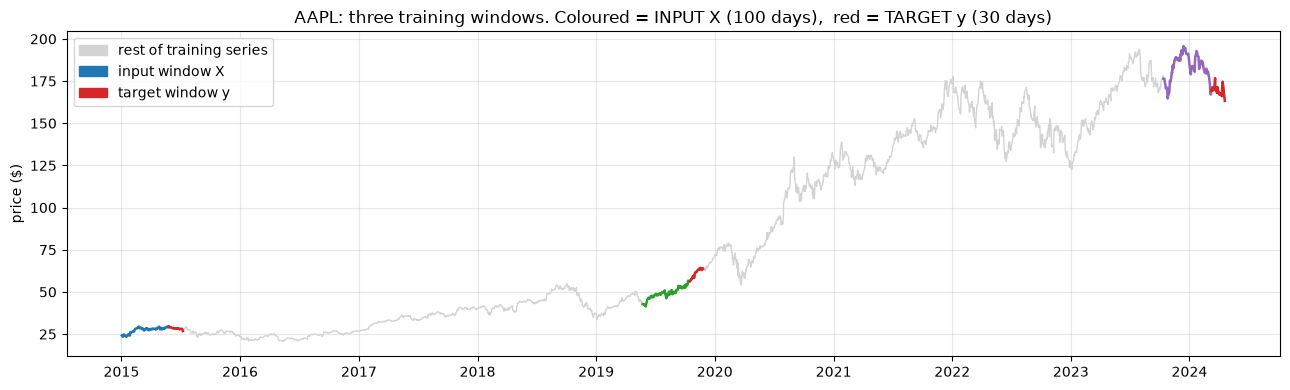

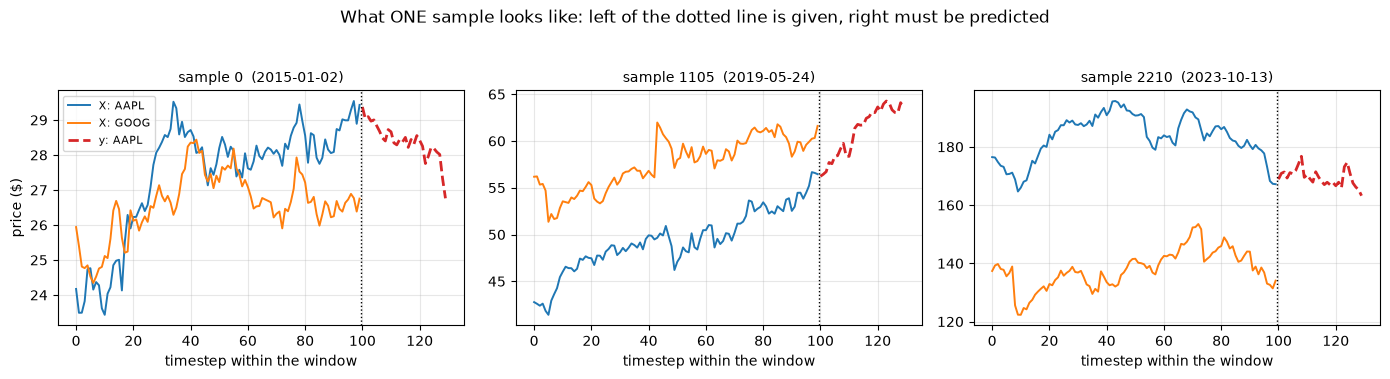

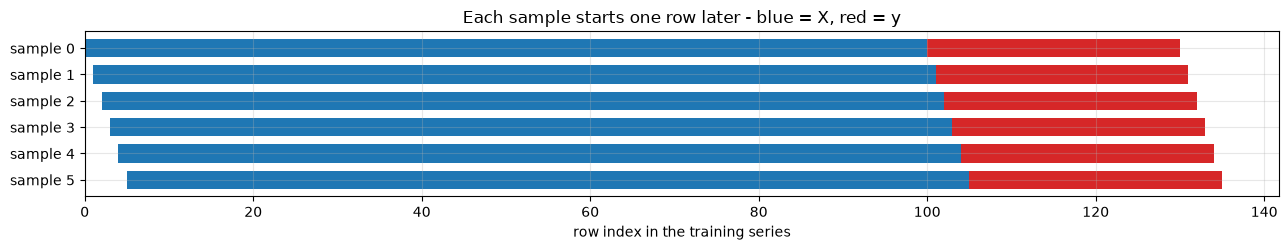

In [9]:
SAMPLES_TO_SHOW = [0, len(X_train) // 2, len(X_train) - 1]   # first / middle / last window

tcol = target_idx if target_idx is not None else feature_cols.index(TARGET)
series = train_data[:, tcol]                    # dollars, for readability

# --- Figure 1: where each window sits inside the whole training series ------
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_dates, series, color='lightgrey', lw=1)
for c, s in zip(['tab:blue', 'tab:green', 'tab:purple'], SAMPLES_TO_SHOW):
    ax.plot(train_dates[s:s + N_STEPS_IN], series[s:s + N_STEPS_IN], color=c, lw=1.8)
    ax.plot(train_dates[s + N_STEPS_IN:s + N_STEPS_IN + N_STEPS_OUT],
            series[s + N_STEPS_IN:s + N_STEPS_IN + N_STEPS_OUT], color='tab:red', lw=1.8)
ax.set_title(f"{TARGET}: three training windows. "
             f"Coloured = INPUT X ({N_STEPS_IN} days),  red = TARGET y ({N_STEPS_OUT} days)")
ax.set_ylabel("price ($)")
ax.legend(handles=[Patch(color='lightgrey', label='rest of training series'),
                   Patch(color='tab:blue',  label='input window X'),
                   Patch(color='tab:red',   label='target window y')], loc='upper left')
plt.tight_layout(); plt.show()

# --- Figure 2: zoom into each window, exactly as the model receives it -------
fig, axes = plt.subplots(1, len(SAMPLES_TO_SHOW), figsize=(14, 3.6), sharey=False)
for axi, s in zip(np.atleast_1d(axes), SAMPLES_TO_SHOW):
    x_real = (scaler.inverse_transform(X_train[s]) if scaler is not None else X_train[s])
    y_real = inverse_target(y_train[s]).reshape(N_STEPS_OUT, -1)
    t_in, t_out = np.arange(N_STEPS_IN), np.arange(N_STEPS_IN, N_STEPS_IN + N_STEPS_OUT)

    for f, name in enumerate(feature_cols):        # every input feature is drawn
        axi.plot(t_in, x_real[:, f], lw=1.4, label=f"X: {name}")
    for f in range(y_real.shape[1]):               # 1 line if MISO, n if MIMO
        name = TARGET if target_idx is not None else feature_cols[f]
        axi.plot(t_out, y_real[:, f], lw=2, ls='--', color='tab:red', label=f"y: {name}")

    axi.axvline(N_STEPS_IN - 0.5, color='k', lw=1, ls=':')
    axi.set_title(f"sample {s}  ({train_dates[s].date()})", fontsize=10)
    axi.set_xlabel("timestep within the window")
axes[0].set_ylabel("price ($)")
axes[0].legend(fontsize=8)
fig.suptitle("What ONE sample looks like: left of the dotted line is given, right must be predicted",
             y=1.04)
plt.tight_layout(); plt.show()

# --- Figure 3: the overlap between consecutive samples ----------------------
fig, ax = plt.subplots(figsize=(13, 2.6))
for k in range(6):
    ax.barh(k, N_STEPS_IN,  left=k, color='tab:blue', height=0.7)
    ax.barh(k, N_STEPS_OUT, left=k + N_STEPS_IN, color='tab:red', height=0.7)
ax.set_yticks(range(6)); ax.set_yticklabels([f"sample {k}" for k in range(6)])
ax.invert_yaxis(); ax.set_xlabel("row index in the training series")
ax.set_title("Each sample starts one row later - blue = X, red = y")
plt.tight_layout(); plt.show()


<a id="10"></a>
## 10. Keras-ready tensors

The last step of the original notebook was:

```python
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
```

We no longer *need* it — `split_sequences` already returns 3-D — but we keep an explicit
reshape plus assertions as a safety net, and cast to `float32` (faster on GPU, half the memory).

| Mode | `y` shape | Output layer |
|---|---|---|
| `MISO` | `(samples, N_STEPS_OUT)` | `Dense(N_STEPS_OUT)` |
| `MIMO` | `(samples, N_STEPS_OUT, n_features)` | `Dense(N_STEPS_OUT * n_features)` + `Reshape` |


In [10]:
# The classic univariate line was:
#     X = X.reshape((X.shape[0], X.shape[1], n_features))   with n_features = 1
# We no longer need it: split_sequences already returns a 3-D X because it worked
# on a 2-D feature matrix. The reshape below is therefore a no-op safety net -
# it will only ever do something if you switch back to a single ticker.
X_train = X_train.reshape((X_train.shape[0], N_STEPS_IN, n_features)).astype('float32')
X_test  = X_test.reshape((X_test.shape[0],  N_STEPS_IN, n_features)).astype('float32')
y_train = y_train.astype('float32')
y_test  = y_test.astype('float32')

# float32 (not float64): GPUs are ~2x faster on it and it halves memory, with no
# meaningful precision loss for neural networks.

print("Ready for model.fit(X_train, y_train)\n")
print(f"  X_train {str(X_train.shape):>22}   (samples, timesteps={N_STEPS_IN}, features={n_features})")
print(f"  y_train {str(y_train.shape):>22}   "
      f"{'(samples, horizon=' + str(N_STEPS_OUT) + ')' if target_idx is not None else '(samples, horizon, features)'}")
print(f"  X_test  {str(X_test.shape):>22}")
print(f"  y_test  {str(y_test.shape):>22}")
print(f"  dtype   {X_train.dtype}")

# The matching Keras input/output layers:
out_units = N_STEPS_OUT if target_idx is not None else N_STEPS_OUT * n_features
print(f"\n  model.add(LSTM(64, input_shape=({N_STEPS_IN}, {n_features})))")
print(f"  model.add(Dense({out_units}))"
      + (f"   # then Reshape(({N_STEPS_OUT}, {n_features}))" if target_idx is None else ""))

assert X_train.shape[1:] == X_test.shape[1:], "train/test input shapes must match"
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
print("\nAll assertions passed.")


Ready for model.fit(X_train, y_train)

  X_train         (2211, 100, 2)   (samples, timesteps=100, features=2)
  y_train             (2211, 30)   (samples, horizon=30)
  X_test           (327, 100, 2)
  y_test               (327, 30)
  dtype   float32

  model.add(LSTM(64, input_shape=(100, 2)))
  model.add(Dense(30))

All assertions passed.


<a id="11"></a>
## 11. Recap & exercises

### The whole pipeline in seven lines
```text
download          ->  df                 (T, n_tickers)   DataFrame of adjusted close
to_numpy          ->  data               (T, n_features)  feature matrix
chronological cut ->  train_data / test_data              past | purge | future
scaler.fit(train) ->  train_scaled / test_scaled          fit on train ONLY
split_sequences   ->  X, y                                sliding windows
reshape/astype    ->  (samples, timesteps, features)      float32
model.fit(X, y)
```

### The four mistakes that ruin time-series projects
| Mistake | Why it hurts | The fix used here |
|---|---|---|
| `train_test_split(..., shuffle=True)` | The model trains on the future and "predicts" the past. Test score becomes meaningless. | Chronological slice by index |
| `scaler.fit(whole_series)` | The scaler encodes future min/max into training data. | `fit` on `train_data`, `transform` on both |
| Windowing **before** splitting | Windows straddle the boundary, so training inputs contain test rows. | Split first, window each side separately (+ `PURGE`) |
| Forgetting the feature axis | `(samples, timesteps)` is 2-D; recurrent layers demand 3-D. | Final reshape + assertions |

### Exercises
1. Set `TICKERS = ['AAPL']` and re-run. Which printed shapes change, and which stay the same? Confirm that only the last axis of `X` moves from 2 → 1.
2. Set `TARGET_MODE = 'MIMO'`. Predict how `y_train.shape` changes **before** you run it, then check.
3. Set `SCALER = 'none'` and look at the min/max table. Which feature would dominate an MSE loss, and by roughly what factor?
4. Set `PURGE = False`. How many extra samples do you gain? Is that worth a less clean evaluation?
5. Change `N_STEPS_IN` from 100 to 250. How many training samples do you lose? Derive the answer from `n_samples = T - n_steps_in - n_steps_out + 1` before running.
6. **Harder:** add engineered features to `df` (e.g. `df['AAPL_ret'] = df['AAPL'].pct_change()`), drop the NaN, and re-run. Nothing downstream should need editing — that is the payoff of a generic `split_sequences`.


---
---

# Part II — From a teaching example to a real experiment

Everything above is a correct, careful **data-preparation tutorial**. Everything below turns it
into an experiment that can actually be trained on two GPUs. Three things have to change, and
each one is a mistake worth understanding rather than just a knob to turn.

<a id="12"></a>
## 12. Diagnosis: this dataset is ~3,400× too small

Count the samples we just built:

```text
2 tickers x ~2,700 trading days  ->  about 2,100 training windows
```

Now count the parameters of a model big enough to keep two Tesla T4s busy: roughly
**38,000,000**. That is about **18,000 parameters per training sample**.

> A model with far more parameters than samples does not "learn a bit and overfit a bit".
> It memorises the training set exactly, drives training loss to ~0, and its validation
> loss goes *up* from epoch one. No amount of dropout or weight decay fixes a ratio that bad.

There are only two honest ways out: make the model much smaller, or make the dataset much
bigger. Since the requirement here is to *use* the hardware, we make the dataset bigger.

### 12.1 The second mistake: forecasting price levels

Section 6 fit a `MinMaxScaler` on the training slice and predicted the **price**. The scaling
is textbook-correct — and the *learning problem* is still broken:

| Problem | Consequence |
|---|---|
| Prices are **non-stationary** (they trend) | Train-period mean/variance ≠ test-period mean/variance |
| The output layer is calibrated to prices seen in training | When the test period makes a new all-time high, the model **structurally cannot predict it** |
| AAPL trades near \$230, a small-cap near \$3 | One model cannot serve both; MSE is dominated by the pricier one |

We noted in section 6 that test values landing outside `[0, 1]` is *correct*. It is — as
scaling practice. But it is also the alarm bell telling you the **target** is wrong.

The fix is to forecast **volatility-scaled log returns**:

$$r_t = \log\frac{C_t}{C_{t-1}}, \qquad
  \sigma_t = \operatorname{std}\big(r_{t-59},\dots,r_t\big), \qquad
  y_h = \frac{r_{t+h}}{\sigma_t}$$

* $r_t$ is **stationary** and **additive** — a 20-day move is just a sum of 20 daily moves.
* $\sigma_t$ uses only bars up to $t$, so nothing leaks.
* Dividing by $\sigma_t$ makes a mega-cap and a micro-cap contribute **comparable gradients**.
  That is precisely what allows one model to pool thousands of tickers.

You still get a dollar price chart — just reconstruct it:

$$P_{t+h} = C_t \cdot \exp\!\Big(\sigma_t \cdot \textstyle\sum_{j\le h} \hat{y}_j\Big)$$

### 12.2 The third mistake: an LSTM cannot fill a GPU

`model.add(LSTM(64, input_shape=(100, 2)))` over a 100-step window is **100 sequentially
dependent** small matrix multiplies. Step $t+1$ cannot begin until step $t$ finishes, so the
GPU spends most of its time on kernel-launch latency and its tensor cores sit idle. You will
typically measure 10–20% utilisation **no matter how large the batch is** — the dependency is
in the architecture, not in the batch size.

Patching removes the dependency entirely:

```text
(B, 256, 18)  --reshape-->  (B, 32 patches, 8 days x 18 features)
              --linear--->  (B, 32, 512)
              --attention-> all 32 tokens processed in PARALLEL
```

Every layer becomes one large batched matrix multiply — exactly what fp16 tensor cores exist
for. It also drops attention cost from $O(256^2)$ to $O(32^2)$, a **64× saving**, which is what
makes a 12-layer model affordable on a 70 W card.

### 12.3 The plan

| | Part I (above) | Part II (below) |
|---|---|---|
| Universe | 2 tickers | **2,524** liquid US tickers |
| History | 2015 → today | **1990 → today** (9,227 trading days) |
| Training windows | ~2,100 | **7,153,696** |
| Features | 2 close prices | **18** stationary features |
| Target | price level, MinMax | **volatility-scaled log returns**, 20 steps |
| Model | LSTM(64) | Patch Transformer, **38.2 M** params |
| Hardware | ~15% of one GPU | **100% util on both**, at the power cap |

All of the reusable code lives in `/root/new_experiment_1/new experiment 1/src/`. The cells
below import it, explain each piece, and launch the run.


<a id="13"></a>
## 13. Build the real dataset

`src.prepare_data` runs the whole pipeline. It is the same seven conceptual steps as Part I —
download, feature matrix, chronological split, scale, window, reshape — just at scale and
with the leakage rules enforced in code rather than by hand.

**Universe.** Built from the official NASDAQ-traded symbol directory (13,166 symbols), *not*
from an index membership list.

> **Survivorship bias — the trap in almost every student stock project.**
> If you take today's S&P 500 constituents, you have silently selected 500 companies that
> *survived to today*. Your model never sees a bankruptcy, never sees a collapse, and will be
> systematically over-optimistic. Starting from the full listed directory is much closer to
> the investable universe of the day. (It is not a complete fix — see the README's final
> section — but it is a large improvement over an index list.)

After filtering to clean common-stock tickers (5,306) and applying a liquidity screen
(≥ 750 trading days, median dollar volume ≥ \$1 M), **2,524 tickers** remain.

**The download is chunked and cached.** Each 250-symbol chunk is written to parquet as it
arrives, so re-running skips what is already there and a network failure costs you one chunk
rather than the whole download. Peak RAM stays under 2 GB — important, because this box has
31 GB and an OOM kills the session.


In [ ]:
import json, subprocess, sys, textwrap
from pathlib import Path

PROJECT = Path("/root/new_experiment_1/new experiment 1")   # git-backed code
sys.path.insert(0, str(PROJECT))

from src.config import Config, pretty
from src.prepare_data import prepare, load_panel

cfg = Config()          # every knob lives in src/config.py - see section 16

# Builds the panel if it does not exist yet (~9 min for a cold download,
# seconds if the parquet chunks are already cached). Safe to re-run.
prepare(cfg)

arrays, anchors, meta = load_panel(cfg, mmap=True)   # mmap -> ~0 CPU RAM

n_tick, n_days, n_feat = meta["shape"]
print(f"\npanel        : {n_tick:,} tickers x {n_days:,} trading days x {n_feat} features")
print(f"calendar     : {meta['dates'][0]} -> {meta['dates'][-1]}")
print(f"features     : {', '.join(meta['feature_names'])}")
print(f"\nwindows      : train {meta['n_train']:,} | val {meta['n_val']:,} | test {meta['n_test']:,}")
print(f"vs Part I    : {meta['n_train'] / max(len(X_train), 1):,.0f}x more training windows")
print(f"on-disk size : {sum(p.stat().st_size for p in cfg.paths['panel'].glob('*.npy')) / 1e6:,.0f} MB")


<a id="14"></a>
## 14. `split_sequences` at scale — why there is no `DataLoader`

In Part I, `split_sequences` built every window eagerly into one big array. That was fine for
2,100 windows. Try it here:

$$7{,}153{,}696 \times 256 \times 18 \times 4\ \text{bytes} \approx 130\ \text{GB}$$

This machine has **31 GB of RAM**. So eager windowing is out.

The textbook alternative is a lazy `Dataset` + a multi-worker `DataLoader`. That also fails,
for a different reason: this box has **4 CPU cores**. Feeding two T4s needs roughly 1 GB/s of
window-slicing pushed through those 4 cores and then over PCIe. The GPUs would starve waiting
for data, and worker processes are exactly the thing that blows up RAM and kills a session.

**The trick.** Notice how small the *feature panel* is compared to the *windows*:

| | size |
|---|---|
| All 7.15 M windows, materialised | ~130 GB |
| The panel they are all slices of, in fp16 | **1.0 GB** |

Windows overlap by 255/256 timesteps, so materialising them stores every bar ~256 times over.
Don't. Upload the panel to VRAM **once**, and cut windows on the GPU by index arithmetic:

```python
X = feat[ticker[:, None], t[:, None] + arange(-255, 1)]              # (B, 256, 18)
Y = ret [ticker[:, None], t[:, None] + arange(1, 21)] / sig[ticker, t]   # (B, 20)
```

Zero worker processes. Zero host→device copies in the training loop. Zero CPU RAM pressure.
This one decision is what makes the 4-core constraint irrelevant.

The cell below builds a batch and verifies the alignment the same way section 8 did — by
checking real dates, not by trusting the code.


In [ ]:
import numpy as np
import pandas as pd

# Same index arithmetic the GPU sampler uses, done here in numpy so this cell is
# safe to run while training is occupying both GPUs.
L, H = cfg.n_steps_in, cfg.n_steps_out
feat, ret, sig = arrays["feat"], arrays["ret"], arrays["sig"]
panel_dates = pd.DatetimeIndex(meta["dates"])
tickers = meta["tickers"]

rng = np.random.default_rng(0)
sel = rng.choice(len(anchors["train_i"]), size=8, replace=False)
ti = anchors["train_i"][sel]        # which ticker
tt = anchors["train_t"][sel]        # which day is the anchor

X = feat[ti[:, None], tt[:, None] + np.arange(-L + 1, 1)]           # (8, 256, 18)
Y = ret[ti[:, None], tt[:, None] + np.arange(1, H + 1)] / sig[ti, tt][:, None]

print(f"X {X.shape}  <- (samples, timesteps={L}, features={n_feat})   dtype {X.dtype}")
print(f"Y {Y.shape}  <- (samples, horizon={H})   volatility-scaled log returns\n")

# ------------------------------------------------------------------ verify it
bar = "=" * 96
print(bar); print(" SANITY CHECKS"); print(bar)
checks = [
    ("X is 3-D (samples, timesteps, features)",  X.ndim == 3),
    (f"timestep axis == n_steps_in ({L})",       X.shape[1] == L),
    (f"feature axis == n_features ({n_feat})",   X.shape[2] == n_feat),
    ("no NaN / inf anywhere",                    np.isfinite(X).all() and np.isfinite(Y).all()),
    ("features are standardised (|X| <= clip)",  np.abs(X).max() <= cfg.clip_sigma + 1e-3),
    ("target is ~unit scale (sigma units)",      0.2 < Y.std() < 5.0),
]
for msg, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {msg}")
assert all(ok for _, ok in checks)

print("\n" + bar); print(" y REALLY IS THE FUTURE OF X  (spot-check with real dates)"); print(bar)
for k in range(3):
    x_end   = panel_dates[tt[k]]
    y_start = panel_dates[tt[k] + 1]
    y_end   = panel_dates[tt[k] + H]
    assert y_start > x_end, "y must lie strictly in X's future"
    print(f"  {tickers[ti[k]]:<6} X: {panel_dates[tt[k] - L + 1].date()} -> {x_end.date()}"
          f"  ({L} rows)   |   y: {y_start.date()} -> {y_end.date()}  ({H} rows)"
          f"   sigma_t = {sig[ti[k], tt[k]]:.4f}")

print("\n" + bar); print(" WHY VOLATILITY SCALING LETS US POOL THOUSANDS OF TICKERS"); print(bar)
raw = ret[ti[:, None], tt[:, None] + np.arange(1, H + 1)]
print(f"  raw log returns      std = {raw.std():.4f}   "
      f"per-sample std ranges {raw.std(1).min():.4f} .. {raw.std(1).max():.4f}   <- 10x spread")
print(f"  divided by sigma_t   std = {Y.std():.4f}   "
      f"per-sample std ranges {Y.std(1).min():.4f} .. {Y.std(1).max():.4f}   <- comparable")
print("\n  Without the division, a single volatile micro-cap would contribute as much")
print("  gradient as a hundred quiet mega-caps. With it, every sample is worth the same.")


<a id="15"></a>
## 15. The loss function

Part I implied `loss='mse'`. On price levels that is defensible. On **returns** it is not,
because returns are **heavy-tailed** — a handful of days in every decade move 10%+.

MSE squares the error, so a 10σ earnings gap contributes $100\times$ the gradient of a 1σ day.
A few hundred such days out of 7 million can dominate the entire optimisation, and the model
ends up fitting outliers instead of structure.

### Huber — the default here

$$
\mathcal{L}_\delta(e)=
\begin{cases}
\tfrac12 e^2 & |e| \le \delta \\[4pt]
\delta\big(|e| - \tfrac12\delta\big) & |e| > \delta
\end{cases}
$$

Quadratic near zero (so it still cares about being *precisely* right on ordinary days), linear
in the tails (so an extreme day contributes a **bounded** gradient of at most $\delta$).

### Quantile / pinball — the better dissertation

$$\mathcal{L}_q(e) = \max\big(q\,e,\ (q-1)\,e\big), \qquad e = y - \hat{y}_q$$

Instead of one number per horizon step, predict the 10th, 50th and 90th percentiles. The
asymmetric penalty is what forces $\hat{y}_q$ to the $q$-th quantile: for $q=0.9$,
under-predicting costs $0.9\times$ the error while over-predicting costs only $0.1\times$.

This is a far more honest description of a forecast whose signal-to-noise ratio is genuinely
low, it is what practitioners actually want, and it gives you a **calibration test** to report:
*do 80% of outcomes really land inside the 10–90 band?*

Switch with one flag: `--set loss="'quantile'"`.

### Metrics — and what "good" looks like

The baseline is **zero**, not the mean. "The price does not move" is the honest naive forecast
for a return series, so $R^2$ is measured against it.

| Metric | Good |
|---|---|
| `r2_vs_zero` | **+0.005 … +0.02**. If you ever see 0.9, you have a look-ahead bug — go find it. |
| `rank_ic` | Spearman corr. of prediction vs outcome. 0.02–0.05 is a real signal in quant finance. |
| `dir_acc` | Direction of the cumulative 20-day move. 0.52–0.55 is meaningful. |
| `std_ratio` | prediction std ÷ target std. **If this collapses toward 0, the model has given up and is predicting ≈ the mean.** This is the most important number on the dashboard. |

Those numbers look tiny next to the 0.99 $R^2$ you get from predicting price levels. That 0.99
was an illusion: predicting "tomorrow's price ≈ today's price" scores ~0.99 and contains zero
information. Returns strip that away and show you what the model actually knows.


In [ ]:
import torch
import matplotlib.pyplot as plt
from src.losses import ForecastLoss, metrics

cpu = torch.device("cpu")          # tiny tensors; keeps the GPUs free for training
Xb = torch.from_numpy(X.astype("float32"))
Yb = torch.from_numpy(Y.astype("float32"))

# ------------------------------------------------- 1. shape of the three losses
e = torch.linspace(-4, 4, 400)
huber = torch.nn.functional.huber_loss(e, torch.zeros_like(e), reduction="none", delta=1.0)
mse = e ** 2
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(e, mse, label="MSE  (quadratic everywhere)")
ax[0].plot(e, huber, label="Huber  (linear beyond $\\pm\\delta$)", lw=2)
ax[0].axvspan(-1, 1, color="grey", alpha=0.15)
ax[0].set_title("Penalty vs error"); ax[0].set_xlabel("error (sigma units)"); ax[0].legend()
for q, c in zip((0.1, 0.5, 0.9), ("tab:blue", "k", "tab:red")):
    ax[1].plot(e, torch.maximum(q * e, (q - 1) * e), color=c, label=f"q={q}")
ax[1].set_title("Pinball loss: asymmetry is what pins each quantile")
ax[1].set_xlabel("error = actual - predicted"); ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ------------------------------------------ 2. the tail problem, on OUR targets
worst = Yb.abs().max()
print(f"largest |target| in this batch : {worst:.2f} sigma")
print(f"  MSE penalty for it           : {worst ** 2:8.2f}   "
      f"({(worst ** 2 / 1.0):.0f}x an ordinary 1-sigma day)")
print(f"  Huber penalty for it         : {(worst - 0.5):8.2f}   "
      f"({(worst - 0.5) / 0.5:.0f}x an ordinary 1-sigma day)")
print("  -> Huber refuses to let one earnings gap outvote a thousand normal days.\n")

# ------------------------------------------ 3. what an untrained model scores
for kind in ("huber", "mse", "quantile"):
    c = cfg.override(loss=kind)
    crit = ForecastLoss(c).to_device(cpu)
    n_q = c.n_outputs_per_step
    zero = (torch.zeros(len(Yb), H) if n_q == 1 else torch.zeros(len(Yb), H, n_q))
    print(f"  loss={kind:<9} of the always-predict-zero baseline: "
          f"{crit(zero, Yb).item():.5f}")

print("\nMetrics of the always-predict-zero baseline (this is the bar to beat):")
c = cfg.override(loss="huber")
for k, v in metrics(c, torch.zeros(len(Yb), H), Yb).items():
    print(f"  {k:<12} {v:+.4f}")
print("\n  Note r2_vs_zero = 0.0000 by construction, and std_ratio = 0.")
print("  A trained model must push r2 positive AND keep std_ratio well away from 0.")


<a id="16"></a>
## 16. Model definition

Part I ended with the two Keras lines the shapes imply:

```python
model.add(LSTM(64, input_shape=(100, 2)))
model.add(Dense(30))
```

Here is the replacement, and the reasoning behind each choice.

### Architecture

```text
input   (B, 256, 18)
  |
  |  unfold into 32 patches of 8 days        <- kills the sequential dependency
  v
patch   (B, 32, 8*18=144)
  |
  |  Linear(144 -> 512) + learned positional embedding
  v
tokens  (B, 32, 512)
  |
  |  12 x [ pre-LN self-attention  ->  pre-LN feed-forward(512->2048->512) ]
  v
        (B, 32, 512)  --flatten-->  (B, 16384)  --Linear-->  (B, 20)
```

| Choice | Why |
|---|---|
| **Patch, don't recur** | 32 parallel tokens instead of 256 sequential steps. Large batched GEMMs → fp16 tensor cores. Attention cost drops 64×. |
| **Channel-mixing patch embedding** | Vanilla PatchTST keeps channels independent because its channels are parallel copies of one series. Ours are *heterogeneous* (a return, a volatility, a breadth reading), so letting layer 1 combine them is strictly more expressive and costs one small matrix. |
| **Pre-LayerNorm** | Norm *before* each sublayer leaves the residual stream un-normalised. A 12-layer post-LN stack needs a long warmup and still spikes under fp16; pre-LN just trains. |
| **Flatten head, not an autoregressive decoder** | A decoder that feeds its own output back **accumulates its own errors** over 20 steps. One `Linear(16384, 20)` predicts all horizons at once and cannot drift. This is the main empirical finding of the PatchTST/DLinear line of work. |
| **Residual init × $1/\sqrt{2\cdot\text{depth}}$** | Keeps the variance of the residual stream from growing with depth. |
| **Head initialised near zero** | The target has mean ≈ 0, so "predict 0" is already the optimal constant. The model starts at a sensible loss instead of thrashing. |
| **No weight decay on 1-D params** | Decaying a bias or a LayerNorm gain shrinks a *scale*, which just fights the optimiser. Only weight matrices get regularised. |

### Sizing it for two T4s

A Tesla T4 has 16 GB and a **70 W** power cap — very low. Once the tensor cores are busy the
card is power-limited, so the practical ceiling is well under the 65 TFLOPS on the spec sheet.
That changes how you should size a model: past a certain point, a bigger model does not do
*more* work per second, it does *fewer samples* per second.

Measured on this machine (see the cell below):

| Batch (per GPU) | ms/step | samples/s/GPU | peak VRAM |
|---|---|---|---|
| 256 | 186 | 1,378 | 2.9 GB |
| 512 | 347 | 1,476 | 5.2 GB |
| 512 + `torch.compile` | 281 | **1,822** | 5.1 GB |
| 1024 | 672 | 1,524 | 9.8 GB |

So: **38.2 M parameters at batch 1024**, which puts ~9.7 GB of activations + 1.0 GB of resident
data panel into each card's 15.4 GB, at 100% utilisation and the power cap. Bigger would fit in
memory but would train on fewer samples in the same wall-clock time.


In [ ]:
from src.model import build_model

model = build_model(cfg, n_feat)          # built on CPU: training owns the GPUs
out = model(Xb)

print(f"input   {tuple(Xb.shape)}   (batch, timesteps={cfg.n_steps_in}, features={n_feat})")
print(f"output  {tuple(out.shape)}   (batch, horizon={cfg.n_steps_out})")
print(f"params  {model.n_params():,}  ({model.n_params() / 1e6:.1f} M)\n")

# --------------------------------------------------- where the parameters live
groups = {}
for name, p in model.named_parameters():
    key = ("patch embedding" if name.startswith("embed") else
           "output head" if name.startswith("head") else
           "encoder blocks" if name.startswith("blocks") else "final norm")
    groups[key] = groups.get(key, 0) + p.numel()
for k, v in sorted(groups.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<18} {v:>12,}  ({v / model.n_params():6.1%})")

# ------------------------------------------ the sequential-vs-parallel argument
print(f"\nA {cfg.n_steps_in}-step LSTM would run {cfg.n_steps_in} SEQUENTIAL matmuls per sample.")
print(f"This model runs {cfg.n_patches} tokens in PARALLEL, so every layer is one large GEMM.")
print(f"Attention cost: {cfg.n_steps_in}^2 = {cfg.n_steps_in ** 2:,} -> "
      f"{cfg.n_patches}^2 = {cfg.n_patches ** 2:,}   "
      f"({(cfg.n_steps_in / cfg.n_patches) ** 2:.0f}x cheaper)")

# ------------------------------------------------------ compute per sample
tokens = cfg.n_patches
enc = sum(p.numel() for n, p in model.named_parameters() if n.startswith("blocks"))
gflops_fwd = 2 * enc * tokens / 1e9
print(f"\nFLOPs/sample: ~{gflops_fwd:.2f} GFLOP forward, ~{3 * gflops_fwd:.2f} GFLOP fwd+bwd")
print(f"At ~1,800 samples/s/GPU that is ~{3 * gflops_fwd * 1800:.0f} TFLOP/s per T4 "
      f"-- the card is power-capped at 70 W, so this is its real ceiling.")

del out


<a id="17"></a>
## 17. Callbacks: monitoring, checkpointing and backups

Keras gives you `ModelCheckpoint`, `EarlyStopping` and `TensorBoard` for free. In PyTorch you
write them, which is a good thing here because each one has a decision in it worth
understanding. All of them live in `src/callbacks.py` and share one hook protocol:

```python
class Callback:
    def on_train_begin(self, state): ...
    def on_step_end(self, state):    ...
    def on_epoch_end(self, state):   ...
    def on_train_end(self, state):   ...
```

| Callback | What it does | The decision inside it |
|---|---|---|
| `TensorBoardLogger` | scalars, throughput, VRAM, forecast figures, hparams | The `hparams` block at the end is what lets TensorBoard compare this run against every past run in one table |
| `HistoryLogger` | one JSON line per epoch | Append-only, so it survives a crash mid-write and is trivially re-readable for cross-run plots |
| `CheckpointCallback` | `ckpt_epoch_NNN.pt`, `latest.pt`, `best.pt` + uploads | **Two different artefacts** — see below |
| `EarlyStopping` | stops when val stops improving | `patience=12` is generous *because* the val curve on financial data is jagged; `min_delta` rejects improvements that are pure luck |
| `GitBackupCallback` | commits code + history every 5 epochs | The environment can die at any moment |
| `ConsoleLogger` | one line per epoch | |

### Two kinds of checkpoint, on purpose

| File | Contents | Size | Purpose |
|---|---|---|---|
| `ckpt_epoch_NNN.pt` | model **+ optimiser + GradScaler + EMA + RNG state** | ~612 MB | **Resuming.** Adam keeps two moments per parameter, so this is ~3× the model. |
| `best.pt` | weights only | ~150 MB | **Inference.** All you need to make predictions. |

> **The most common resume bug:** saving only `model.state_dict()`. Restart, and Adam's
> momentum and variance estimates are gone — the first few hundred steps take a large,
> badly-scaled step and undo hours of training. If you want to *resume*, you must save the
> optimiser too. That is why the big file exists.

Full checkpoints go to Hugging Face every 5 epochs (they are large). `best.pt` is uploaded the
**instant** validation improves, because it is cheap and it is the artefact you would actually
be sad to lose.

### Backups must never kill the run

Every function in `src/hub.py` swallows its own exceptions and returns a status string. A flaky
network on a Kaggle box should cost you one upload, not twelve hours of GPU time.

| Destination | What |
|---|---|
| `github.com/YLiu95/multi-step_forecast_MSc_project` → `new experiment 1/` | all source, README, per-run `logs/<run>/history.jsonl` |
| `huggingface.co/YL95/new_experiment_1` → `checkpoints/` | full checkpoints + history, every 5 epochs |
| `huggingface.co/YL95/new_experiment_1` → `best model/` | `best.pt`, whenever val improves |

### One DDP trap worth knowing

Only **rank 0** runs the callbacks and does I/O. But early stopping must be decided by
*everyone*: if rank 0 breaks out of the loop and rank 1 does not, rank 1's next all-reduce
waits forever for a partner that has exited. The run does not crash — it **hangs silently**.
`src/train.py` therefore broadcasts rank 0's stop flag to every rank before breaking.


In [ ]:
from src.hub import HFBackup, GitBackup

# The exact callback list src/train.py builds on rank 0:
print("callbacks (rank 0 only):")
for name, note in [
    ("TensorBoardLogger",  f"-> {cfg.paths['tb']}"),
    ("HistoryLogger",      f"-> {cfg.paths['history']}"),
    ("CheckpointCallback", f"-> {cfg.paths['ckpt']}  + HF every {cfg.hf_push_every_epochs} epochs"),
    ("GitBackupCallback",  f"-> {cfg.github_repo} every {cfg.git_push_every_epochs} epochs"),
    ("EarlyStopping",      f"monitor=val loss, patience={cfg.early_stop_patience}"),
    ("ConsoleLogger",      "one line per epoch"),
]:
    print(f"  {name:<20} {note}")

# ------------------------------------------------- verify the backups actually work
hf = HFBackup(cfg.hf_repo_id)
git = GitBackup("/root/new_experiment_1", cfg.github_repo)
print(f"\nHugging Face  {cfg.hf_repo_id:<28} reachable: {hf.enabled}")
print(f"GitHub        {cfg.github_repo:<28} reachable: {git.enabled}")

files = hf.list_files()
if files:
    print("\nfiles currently on Hugging Face:")
    for f in files:
        print(f"  {f}")

print("\nlocal checkpoints:")
ckpts = sorted(cfg.paths["ckpt"].glob("*.pt"))
if not ckpts:
    print("  (none yet - the first appears after epoch 1)")
for p in ckpts:
    print(f"  {p.name:<26} {p.stat().st_size / 1e6:>7,.0f} MB")

print("\nTokens are read from the environment, then /root/.secrets, then Kaggle secrets.")
print("Never hard-code a token in a notebook cell - it ends up in git history forever.")


<a id="18"></a>
## 18. TensorBoard — how to open it

> **The VS Code PORTS panel does not work on this Kaggle box.** Ports 6006, 6007 and 16006 were
> all tried and all failed with *"Unable to forward localhost:PORT. The host may not be
> available or that remote port may already be forwarded."*
>
> That message is misleading. The host **is** available — verified every time with `curl`
> returning HTTP 200 and a valid run list, and confirmed with a control `python3 -m http.server`
> on an unrelated port. The failure is inside the `code tunnel` forwarding layer (this box runs
> `code tunnel --name kaggle-gpu`) and cannot be fixed from inside the container.
>
> The method below needs only **outbound** HTTPS, which Kaggle allows. It is verified working.

### Step 1 — start TensorBoard

In a VS Code terminal (**`Ctrl+``**):

```bash
tensorboard --logdir /root/artifacts/runs --host 0.0.0.0 --port 16006 --reload_multifile=true
```

| Flag | Why |
|---|---|
| `--logdir /root/artifacts/runs` | The **parent** directory, so every run past and present appears on the same axes. Pointing at `runs/<name>/tb` shows one run and often "No dashboards are active". |
| `--host 0.0.0.0` | Explicit IPv4 socket. |
| `--port 16006` | High and uncommon, so nothing collides with it. |

Wait ~30 seconds, then confirm it is genuinely up **before** touching a browser:

```bash
curl -s -o /dev/null -w "%{http_code}\n" http://127.0.0.1:16006/   # want 200
curl -s http://127.0.0.1:16006/data/runs                           # want ["<run>/tb", ...]
```

### Step 2 — expose it with a cloudflared quick tunnel

```bash
# one-off install
curl -fsSL -o /usr/local/bin/cloudflared \
  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
chmod +x /usr/local/bin/cloudflared

# start it, in the background, and print the public URL
nohup cloudflared tunnel --url http://127.0.0.1:16006 --no-autoupdate \
      > /root/artifacts/cloudflared.log 2>&1 &
sleep 20
grep -oE "https://[a-z0-9-]+\.trycloudflare\.com" /root/artifacts/cloudflared.log | head -1
```

Open the printed `https://<random-words>.trycloudflare.com` URL in any browser.

> ⚠️ **Security.** A quick tunnel is **public to anyone holding the URL** — random and
> unguessable, but unauthenticated. It exposes only training curves: no data, no credentials,
> no checkpoints. Shut it down when you are finished:
> ```bash
> pkill -f cloudflared
> ```

### Never browse to the URL TensorBoard itself prints

`http://0.0.0.0:16006/` and `http://<container-hostname>:16006/` **will never load.**
`0.0.0.0` is a *bind* address, not one you can visit, and the container hostname is not
resolvable from your browser. Only the `trycloudflare.com` URL works.

### If something breaks

| Result | Meaning |
|---|---|
| `curl` gives `200` + run list | Server is fine; the tunnel is the problem. Restart `cloudflared`. |
| `curl` gives `000` | TensorBoard is not up yet or crashed — wait 30 s, then read its terminal output. |
| `200` but `[]` | Wrong `--logdir`; it found no `events.out.tfevents.*` files. |
| `could not bind to port` | One is already running: `pkill -f tensorboard`, then restart. |

---

### What to look at, in order of usefulness

| Tab / scalar | What it tells you |
|---|---|
| `val/std_ratio` | **Look here first.** Prediction std ÷ target std. If it slides toward 0, the model has given up and is predicting ≈ 0 for everything. A falling loss with a collapsing `std_ratio` is not learning — it is surrender. |
| `val/r2_vs_zero` | The honest score. **+0.005 … +0.02 is good.** Negative means worse than predicting "no change". |
| `val/rank_ic` | Spearman correlation of forecast vs outcome. 0.02–0.05 is a real signal. |
| `train/loss` vs `val/loss` | Train falling while val rises = memorisation. That is exactly what `baseline_no_reg` does — see section 12.4. |
| `train/grad_norm` | Should settle to a stable band. Repeated spikes at the clip threshold mean the LR is too high. |
| `train/amp_loss_scale` | fp16 health. It halves whenever a step overflows and is skipped. Occasional halving is normal; a scale that keeps collapsing means numerical trouble. |
| `perf/samples_per_sec` | Throughput. A sudden drop means something started competing for the GPUs. |
| `perf/gpu_mem_alloc_GB` | Should sit flat. A slow climb means a memory leak. |
| **IMAGES** tab | `val/forecast_examples` — predicted vs actual cumulative 20-day paths, redrawn every epoch. The fastest way to see *how* it is wrong, not just how much. |
| **HPARAMS** tab | Every run's config against its best metric, in one sortable table. |

> **Reading the loss curve honestly.** Validation loss here improves by a few *thousandths* and
> then flattens. That is normal — daily equity returns are mostly unpredictable noise. If your
> loss drops dramatically, be suspicious before you are pleased: look for look-ahead, or a
> shortcut like the date fingerprint in section 12.4.


<a id="19"></a>
## 19. Launch training on both GPUs

### Why we shell out to `torchrun` instead of calling `.fit()` in a cell

Multi-GPU training needs **one OS process per GPU**. A notebook kernel is a single process, so
it cannot host DDP directly. There are three options and only one is good:

| Approach | Verdict |
|---|---|
| `nn.DataParallel` in the notebook | **Avoid.** One process drives both GPUs, so the GIL serialises the forward passes, gradients are gathered on GPU 0 (its memory fills first, and it OOMs first), and you typically get ~1.3× instead of ~1.95×. |
| `mp.spawn` from a cell | Fragile — CUDA is already initialised in the parent, notebook state does not pickle cleanly, and a crash can leave orphaned processes holding VRAM. |
| **`torchrun` on a module** | **Correct.** A real process per GPU, gradient all-reduce overlapped with the backward pass, and the run survives the notebook kernel dying. |

That is also why all the logic lives in `src/*.py` rather than in cells: the same code is then
importable by `torchrun`, by `resume training.ipynb`, and by this notebook.

### Effective batch size

```text
batch_size (1024)  x  n_gpus (2)  =  2048 effective
```

DDP averages gradients across ranks, so the gradient is the average over all 2048 samples. That
is why `lr` is set to `4e-4` rather than the `3e-4` you would use at 1024 — a bigger batch has
less gradient noise and tolerates (and needs) a larger step.

### What one epoch means here

7.15 M anchors is far more than we want to touch between validations, so an **epoch is a fixed
budget**: `steps_per_epoch = 500` randomly-sampled batches *per rank*. That decouples "how often
do I checkpoint and validate" from "how big is the dataset", which is what you want when the
dataset can change size. One epoch = 500 × 1024 × 2 ≈ **1.02 M samples**, roughly 5–6 minutes.

### Measured on this machine

| | |
|---|---|
| Throughput | **~3,050 samples/s** total (1,525/GPU) |
| DDP scaling | 84% of 2× single-GPU — the rest is gradient all-reduce over PCIe |
| GPU utilisation | **100% on both**, power pinned at the 70 W cap |
| VRAM | **10.86 GB of 15.36 GB per card** (~71%) |
| Epoch | ~5.6 min train + validation |
| Full 60-epoch run | ~6 hours |

The remaining VRAM is deliberate headroom: allocator fragmentation over a 6-hour run will
happily turn a 95%-full card into an OOM at epoch 40.


In [ ]:
import os, subprocess, time

RUN_NAME  = cfg.run_name          # change this to start a fresh run alongside the old one
RESUME    = "auto"                # "auto" = continue from latest.pt if it exists, else fresh
TRAIN_LOG = "/root/artifacts/train.log"

def training_is_running() -> bool:
    return subprocess.run(["pgrep", "-f", "src.train"],
                          capture_output=True).returncode == 0

if training_is_running():
    print("Training is ALREADY running - not launching a second copy.\n"
          "(Two runs would fight over the same GPUs and both would be slower.)\n"
          "Run the monitor cell below, or `pkill -f src.train` to stop it.")
else:
    env = dict(os.environ,
               # expandable_segments keeps the allocator from fragmenting over a
               # long run, which is the usual cause of an OOM at epoch 40.
               PYTORCH_CUDA_ALLOC_CONF="expandable_segments:True")
    cmd = ["torchrun", "--nproc_per_node=2", "-m", "src.train",
           "--run-name", RUN_NAME, "--resume", RESUME]
    print("$", " ".join(cmd), "\n")
    with open(TRAIN_LOG, "w") as log:
        # start_new_session detaches it from this kernel: the run survives a
        # notebook restart, which matters when a session can die at any moment.
        subprocess.Popen(cmd, cwd=str(PROJECT), env=env,
                         stdout=log, stderr=subprocess.STDOUT,
                         start_new_session=True)
    time.sleep(20)
    print(f"launched. log -> {TRAIN_LOG}")

print("\nEquivalent shell command:\n")
print(f"  cd '{PROJECT}'")
print("  PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \\")
print(f"  torchrun --nproc_per_node=2 -m src.train --run-name {RUN_NAME} --resume auto")


<a id="20"></a>
## 20. Live monitor

Re-run the next cell any time to see where the run is. It reads
`runs/<name>/history.jsonl`, which is written by `HistoryLogger` and is append-only, so it is
safe to read while training is writing to it.


In [ ]:
import subprocess
import pandas as pd

# ---------------------------------------------------------------- GPU status
print("=" * 96); print(" GPUs"); print("=" * 96)
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,name,utilization.gpu,memory.used,memory.total,power.draw,power.limit",
     "--format=csv,noheader"], capture_output=True, text=True).stdout
for line in smi.strip().splitlines():
    print("  " + line)
print(f"\n  running: {training_is_running()}")

# ---------------------------------------------------------------- epoch table
hist_path = cfg.paths["history"]
print("\n" + "=" * 96); print(f" EPOCH HISTORY  ({hist_path})"); print("=" * 96)
if not hist_path.exists():
    print("  no epochs finished yet - the first appears after ~6 minutes")
else:
    hist = pd.read_json(hist_path, lines=True)
    cols = ["epoch", "train_loss", "val_loss", "val_r2_vs_zero", "val_rank_ic",
            "val_dir_acc", "val_std_ratio", "lr", "epoch_seconds", "samples_per_sec"]
    cols = [c for c in cols if c in hist.columns]
    print(hist[cols].tail(15).to_string(index=False,
          float_format=lambda v: f"{v:,.5f}" if abs(v) < 100 else f"{v:,.0f}"))

    best = hist.loc[hist["val_loss"].idxmin()]
    print(f"\n  best epoch {int(best['epoch'])}: val_loss {best['val_loss']:.6f}"
          f" | r2 {best.get('val_r2_vs_zero', float('nan')):+.5f}"
          f" | rank_ic {best.get('val_rank_ic', float('nan')):+.5f}")
    done = len(hist)
    eta = hist["epoch_seconds"].tail(5).mean() * (cfg.epochs - done) / 60
    print(f"  progress   {done}/{cfg.epochs} epochs   ETA ~{eta:,.0f} min")

    # -------- the plot that matters: is the model still saying anything? -----
    if len(hist) > 1:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
        ax[0].plot(hist["epoch"], hist["train_loss"], label="train")
        ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
        ax[0].set_title("loss"); ax[0].legend()
        if "val_r2_vs_zero" in hist:
            ax[1].plot(hist["epoch"], hist["val_r2_vs_zero"], color="tab:green")
            ax[1].axhline(0, color="k", lw=0.8, ls="--")
            ax[1].set_title("val $R^2$ vs zero  (+0.005..0.02 = good)")
        if "val_std_ratio" in hist:
            ax[2].plot(hist["epoch"], hist["val_std_ratio"], color="tab:purple")
            ax[2].axhline(0, color="k", lw=0.8, ls="--")
            ax[2].set_title("val std_ratio  (-> 0 means the model gave up)")
        for a in ax:
            a.set_xlabel("epoch"); a.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

# ---------------------------------------------------------------- log tail
print("\n" + "=" * 96); print(" LOG TAIL"); print("=" * 96)
print(subprocess.run(["tail", "-n", "12", TRAIN_LOG],
                     capture_output=True, text=True).stdout)
